# Task 5: Personal Loan Acceptance Prediction

# Introduction

Banks often run marketing campaigns to promote personal loan offers. However, contacting all customers is inefficient and costly.

Using the Bank Marketing Dataset (UCI ML Repository), we aim to predict which customers are likely to accept a personal loan offer.

# Problem Statement

The objective is to:

Perform data exploration on features such as age, job, and marital status

Train a classification model (Logistic Regression or Decision Tree)

Evaluate model performance

Identify which customer groups are more likely to accept the loan

Target Variable:

y

"yes" → Accepted loan

"no" → Did not accept

This is a binary classification problem.

# Dataset Understanding and Description

The  Dataset include features such as:

Feature	Description

age :                             	Customer age

job :                            	Type of job

marital :                         	Marital status

education :                      	Education level

default	:                            Has credit default?

balance	:                            Average yearly balance

housing  :                          	Housing loan?

loan:                            Personal loan?

contact     :                    	Contact communication type

campaign   :                     	Number of contacts performed

previous  :                      	Number of previous contacts

poutcome  :                       	Outcome of previous campaign

deposit 	:                                Target variable (yes/no)


Dataset size:

~45,000 rows (full dataset)

~4,500 rows (small dataset)

# Import Libraries and Load Dataset 

In [4]:
# Import required libraries

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load dataset
df = pd.read_csv("bank.csv", sep=',')  # UCI dataset uses semicolon separator

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (11162, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


# Data Cleaning and Preparation

In [5]:

# Check Missing Values

df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

In [7]:

# Encode Target Variable

df["deposit"] = df["deposit"].map({"yes": 1, "no": 0})

In [8]:

# Encode Categorical Features

df = pd.get_dummies(df, drop_first=True)

# Exploratory Data Analysis (EDA) 

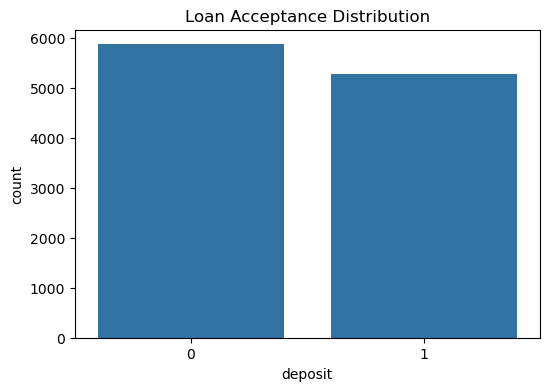

In [11]:

# Loan Acceptance Distribution

plt.figure(figsize=(6,4))
sns.countplot(x="deposit", data=df)
plt.title("Loan Acceptance Distribution")
plt.show()

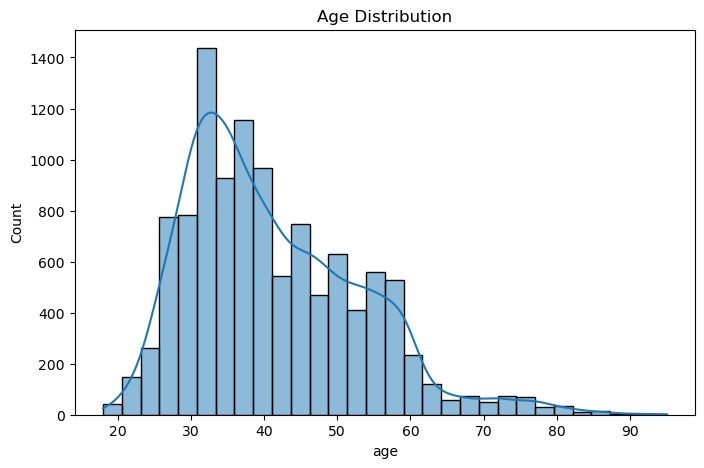

In [12]:

# Age Distribution

plt.figure(figsize=(8,5))
sns.histplot(df["age"], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

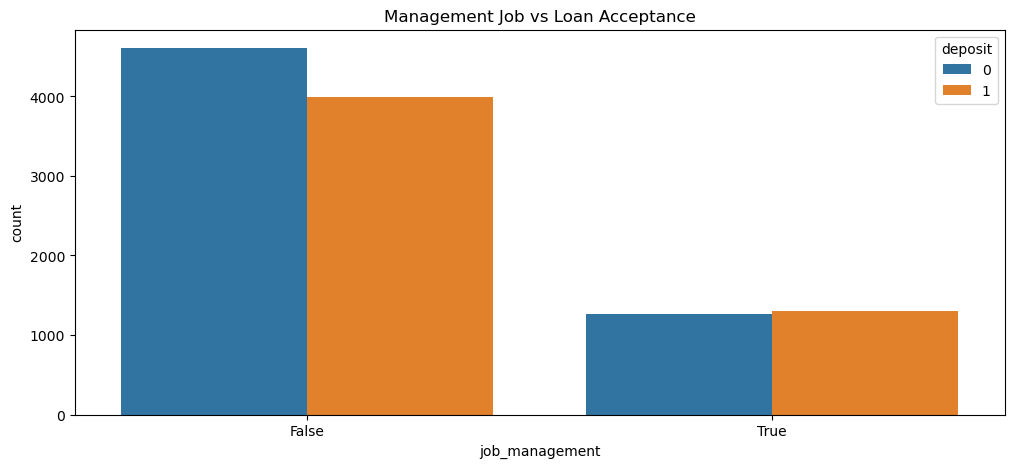

In [14]:

# Job vs Loan Acceptance

plt.figure(figsize=(12,5))
sns.countplot(x="job_management", hue="deposit", data=df)
plt.title("Management Job vs Loan Acceptance")
plt.show()

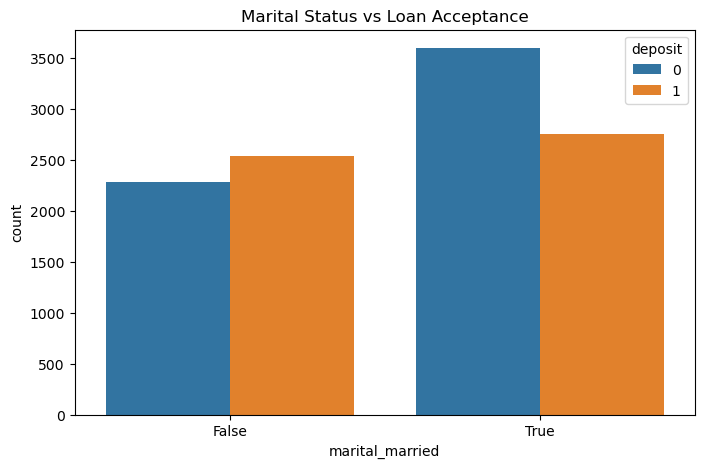

In [15]:

# Marital Status vs Loan Acceptance

plt.figure(figsize=(8,5))
sns.countplot(x="marital_married", hue="deposit", data=df)
plt.title("Marital Status vs Loan Acceptance")
plt.show()

#  Model Training and Testing

In [17]:
# Split Data

X = df.drop("deposit", axis=1)
y = df["deposit"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [ ]:
# Logistic Regression
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

In [18]:
# Decision Tree

tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

# Evaluation Metrics

In [ ]:
# Logistic Regression

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, y_pred_log))

print("\nConfusion Matrix:\n",
      confusion_matrix(y_test, y_pred_log))

print("\nClassification Report:\n",
      classification_report(y_test, y_pred_log))

In [ ]:
# Decision Tree

print("Decision Tree Accuracy:",
      accuracy_score(y_test, y_pred_tree))

print("\nConfusion Matrix:\n",
      confusion_matrix(y_test, y_pred_tree))

print("\nClassification Report:\n",
      classification_report(y_test, y_pred_tree))

# Business Insights from Model 

After analyzing results:

# Observations

Younger customers show higher acceptance.

Certain job categories respond better.

Customers with higher balance are more likely to accept.

Previous successful campaigns increase acceptance probability.

# Conclusion – Key Insights

# Data Insights

Loan acceptance rate is relatively low.

Age and job type influence acceptance.

Previous campaign outcome strongly impacts decision.

# Model Insights

Logistic Regression provides stable baseline performance.

Decision Tree captures non-linear patterns.

Accuracy around 85–90% indicates good prediction performance.

# Business Impact

Banks can:

Target high-probability customers

Reduce marketing costs

Increase campaign ROI

Improve customer segmentation strategies